# CSE 153 Assignment 2: Music Generation

## Task 1: Unconditioned Piano Generation (MAESTRO)
## Task 2: Conditioned Drum Generation given Piano (Lakh MIDI)

We train two models:
1. A GPT-style Transformer on MAESTRO piano MIDI to generate new piano pieces
2. A conditioned LSTM on LMD-matched multi-track MIDI to generate drum patterns given a piano input

The demo: generate a piano piece with Task 1, feed it into Task 2, and hear the result with drums added.

In [6]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from collections import Counter
from miditok import REMI, TokenizerConfig
from miditok.pytorch_data import DatasetMIDI
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

MAESTRO_DIR = Path('maestro-v3.0.0')
LMD_DIR = Path('lmd_matched')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

/opt/anaconda3/envs/cse156/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


---
# Task 1: Unconditioned Piano Generation
---
## 1.1 Exploratory Analysis — MAESTRO Dataset

In [2]:
# Load metadata
meta = pd.read_csv(MAESTRO_DIR / 'maestro-v3.0.0.csv')
print(f'Total pieces: {len(meta)}')
print(f'Years: {sorted(meta["year"].unique())}')
print(f'Total MIDI duration (hours): {meta["duration"].sum() / 3600:.1f}')
meta.head()

Total pieces: 1276
Years: [np.int64(2004), np.int64(2006), np.int64(2008), np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2017), np.int64(2018)]
Total MIDI duration (hours): 198.7


,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433
3,Alexander Scriabin,"24 Preludes Op. 11, No. 13-24",train,2004,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,872.640588
4,Alexander Scriabin,"3 Etudes, Op. 65",validation,2006,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,397.857508


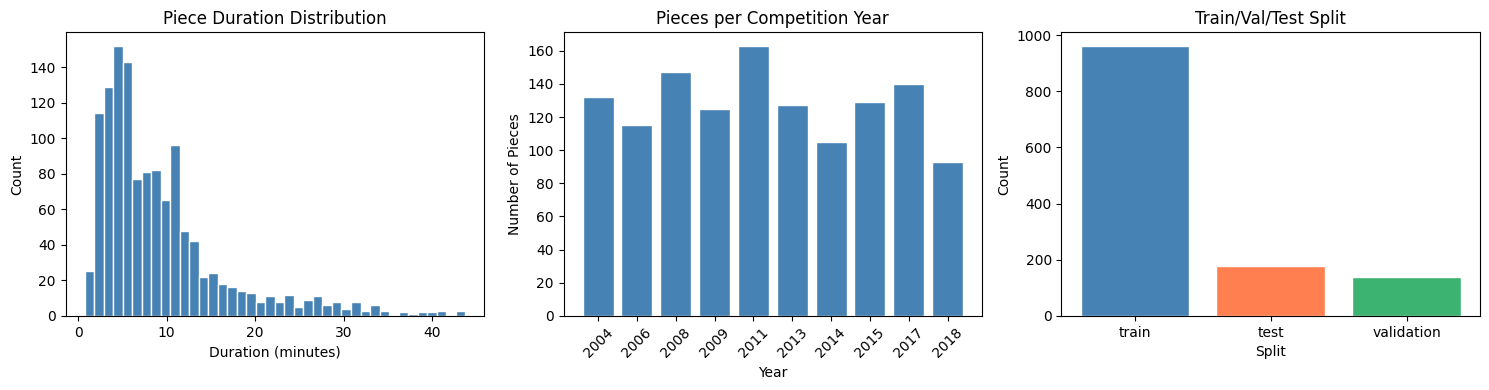

Split counts: {'train': 962, 'test': 177, 'validation': 137}


In [3]:
# Distribution of piece durations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(meta['duration'] / 60, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Piece Duration Distribution')

year_counts = meta['year'].value_counts().sort_index()
axes[1].bar(year_counts.index.astype(str), year_counts.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Pieces')
axes[1].set_title('Pieces per Competition Year')
axes[1].tick_params(axis='x', rotation=45)

split_counts = meta['split'].value_counts()
axes[2].bar(split_counts.index, split_counts.values, color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='white')
axes[2].set_xlabel('Split')
axes[2].set_ylabel('Count')
axes[2].set_title('Train/Val/Test Split')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'maestro_eda.png', dpi=150)
plt.show()
print(f'Split counts: {split_counts.to_dict()}')

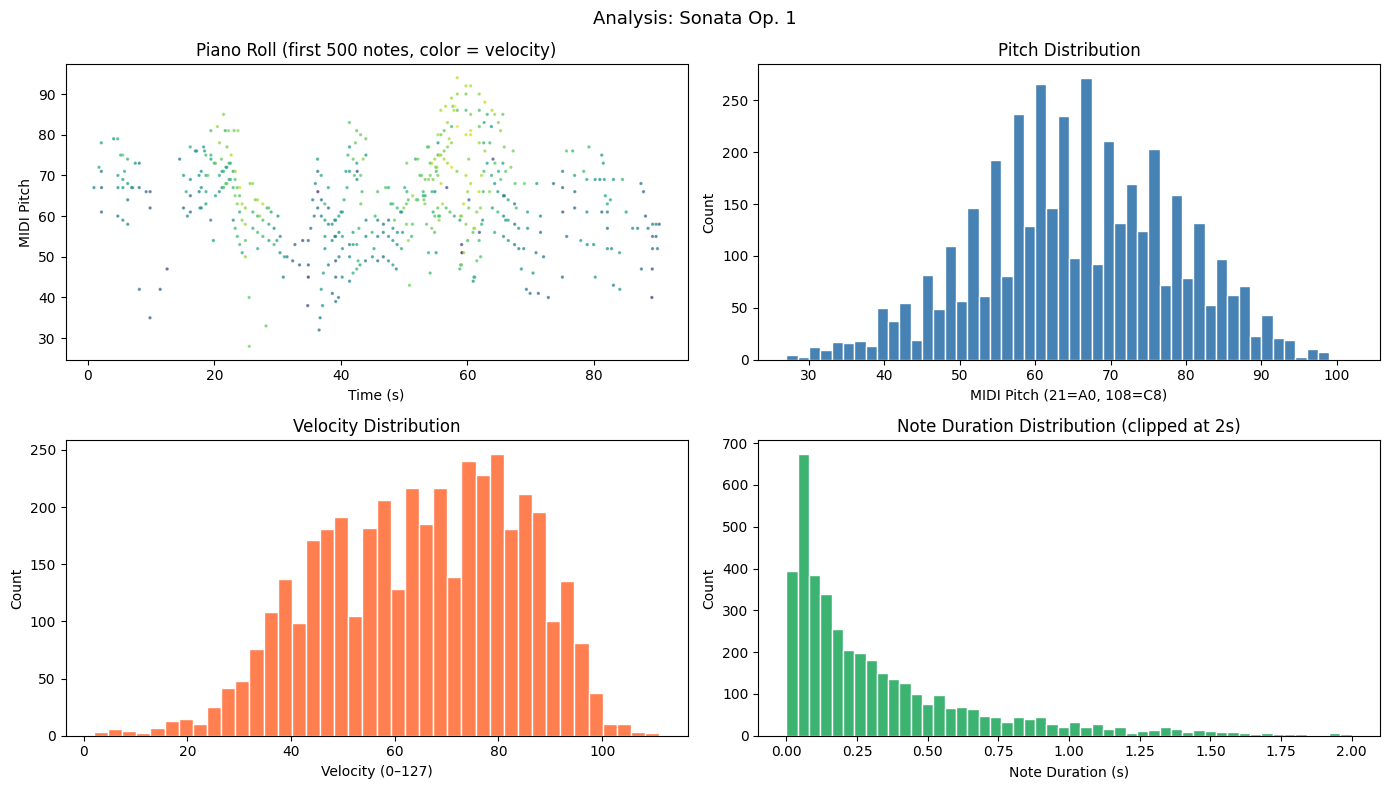

Notes: 4197
Pitch range: 27–102 (D#1–F#7)
Mean velocity: 64.9
Notes per second: 6.0


In [4]:
# Deep dive into a single MIDI file — note density, pitch range, velocity
sample_midi_path = MAESTRO_DIR / meta.iloc[0]['midi_filename']
pm = pretty_midi.PrettyMIDI(str(sample_midi_path))
instrument = pm.instruments[0]
notes = instrument.notes

pitches = [n.pitch for n in notes]
velocities = [n.velocity for n in notes]
durations = [n.end - n.start for n in notes]
onsets = [n.start for n in notes]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Piano roll
axes[0, 0].scatter(onsets[:500], pitches[:500], s=2, alpha=0.6, c=velocities[:500], cmap='viridis')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('MIDI Pitch')
axes[0, 0].set_title('Piano Roll (first 500 notes, color = velocity)')

axes[0, 1].hist(pitches, bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_xlabel('MIDI Pitch (21=A0, 108=C8)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Pitch Distribution')

axes[1, 0].hist(velocities, bins=40, color='coral', edgecolor='white')
axes[1, 0].set_xlabel('Velocity (0–127)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Velocity Distribution')

axes[1, 1].hist(durations, bins=50, color='mediumseagreen', edgecolor='white', range=(0, 2))
axes[1, 1].set_xlabel('Note Duration (s)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Note Duration Distribution (clipped at 2s)')

plt.suptitle(f'Analysis: {meta.iloc[0]["canonical_title"]}', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'maestro_single_piece.png', dpi=150)
plt.show()

print(f'Notes: {len(notes)}')
print(f'Pitch range: {min(pitches)}–{max(pitches)} ({pretty_midi.note_number_to_name(min(pitches))}–{pretty_midi.note_number_to_name(max(pitches))})')
print(f'Mean velocity: {np.mean(velocities):.1f}')
print(f'Notes per second: {len(notes)/pm.get_end_time():.1f}')

Analyzing MAESTRO sample: 100%|██████████| 100/100 [00:19<00:00,  5.13it/s]


Analyzed 100 files
Total notes in sample: 639,174
Mean notes per piece: 6392
Pitch range across dataset: 21–108
Mean velocity: 64.6 ± 19.0


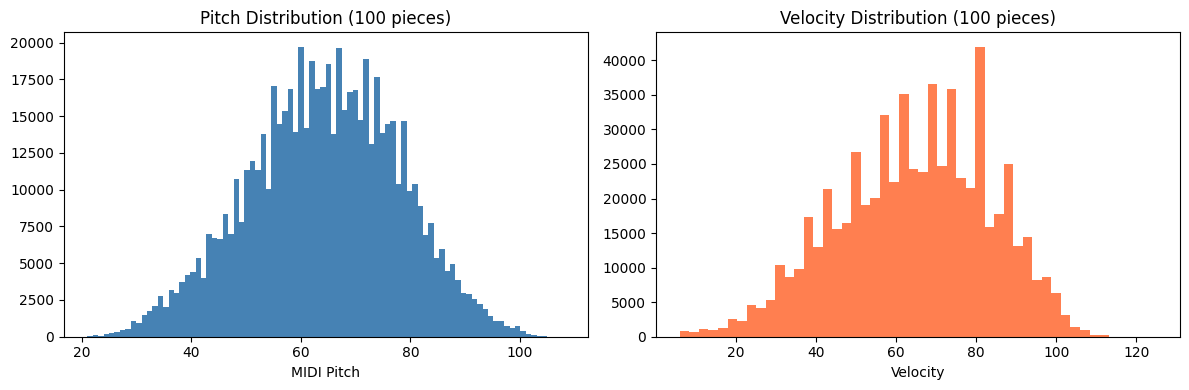

In [5]:
# Aggregate stats across a sample of MAESTRO files
sample_files = list(MAESTRO_DIR.glob('**/*.midi'))[:100]
all_pitches, all_velocities, all_note_counts = [], [], []

for f in tqdm(sample_files, desc='Analyzing MAESTRO sample'):
    try:
        pm = pretty_midi.PrettyMIDI(str(f))
        for inst in pm.instruments:
            if not inst.is_drum:
                all_pitches.extend([n.pitch for n in inst.notes])
                all_velocities.extend([n.velocity for n in inst.notes])
                all_note_counts.append(len(inst.notes))
    except:
        pass

print(f'Analyzed {len(sample_files)} files')
print(f'Total notes in sample: {len(all_pitches):,}')
print(f'Mean notes per piece: {np.mean(all_note_counts):.0f}')
print(f'Pitch range across dataset: {min(all_pitches)}–{max(all_pitches)}')
print(f'Mean velocity: {np.mean(all_velocities):.1f} ± {np.std(all_velocities):.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_pitches, bins=88, color='steelblue', edgecolor='none')
axes[0].set_xlabel('MIDI Pitch')
axes[0].set_title('Pitch Distribution (100 pieces)')
axes[1].hist(all_velocities, bins=50, color='coral', edgecolor='none')
axes[1].set_xlabel('Velocity')
axes[1].set_title('Velocity Distribution (100 pieces)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'maestro_aggregate.png', dpi=150)
plt.show()

## 1.2 Data Preprocessing — REMI Tokenization

We use the **REMI** (Revamped MIDI) tokenization scheme (Huang & Yang, 2020). REMI represents music as a sequence of discrete tokens:
- `Bar` — marks the start of a new bar
- `Position` — beat position within the bar (quantized to 16ths)
- `Pitch` — MIDI note number
- `Velocity` — note velocity (binned)
- `Duration` — note duration (quantized)

This lets us treat music generation as a language modeling problem.

In [6]:
# Build REMI tokenizer on MAESTRO
config = TokenizerConfig(
    num_velocities=16,
    use_chords=False,
    use_rests=True,
    use_tempos=True,
    use_time_signatures=False,
    use_sustain_pedals=False,
    beat_res={(0, 4): 8, (4, 12): 4},
)
tokenizer = REMI(config)

# Collect all MAESTRO MIDI files
maestro_files = list(MAESTRO_DIR.glob('**/*.midi'))
print(f'Total MAESTRO MIDI files: {len(maestro_files)}')

# Train tokenizer vocabulary (builds BPE or just scans vocab)
tokenizer.train(vocab_size=10000, files_paths=maestro_files)
print(f'Vocabulary size: {len(tokenizer)}')

Total MAESTRO MIDI files: 1276
Vocabulary size: 10000


In [9]:
# Inspect tokenization of a single piece
sample_tokens = tokenizer(maestro_files[0])
ids = sample_tokens[0].ids
print(f'Token sequence length: {len(ids)}')
print(f'First 20 token ids: {ids[:20]}')

# Show token type distribution (BPE-merged tokens are labeled as 'BPE')
def safe_token_name(tok_id):
    try:
        return tokenizer[tok_id]
    except KeyError:
        return f'BPE_{tok_id}'

token_names = [safe_token_name(i) for i in ids[:200]]
token_types = [t.split('_')[0] for t in token_names]
type_counts = Counter(token_types)
print('\nToken type breakdown (first 200 tokens):')
for t, c in type_counts.most_common():
    print(f'  {t}: {c}')

Token sequence length: 12819
First 20 token ids: [8986, 55, 7416, 1223, 3262, 436, 197, 1344, 200, 772, 5892, 1106, 4490, 508, 612, 175, 429, 176, 560, 2426]

Token type breakdown (first 200 tokens):
  BPE: 137
  Position: 54
  Pitch: 9


In [10]:
# Build dataset — tokenize all files and chunk into fixed-length sequences
SEQ_LEN = 512  # tokens per training sequence

class MaestroTokenDataset(Dataset):
    def __init__(self, midi_files, tokenizer, seq_len, max_files=None):
        self.seq_len = seq_len
        self.sequences = []
        files = midi_files[:max_files] if max_files else midi_files
        for f in tqdm(files, desc='Tokenizing MAESTRO'):
            try:
                tokens = tokenizer(f)[0].ids
                for i in range(0, len(tokens) - seq_len, seq_len // 2):  # 50% overlap
                    self.sequences.append(torch.tensor(tokens[i:i+seq_len+1], dtype=torch.long))
            except:
                pass
        print(f'Total sequences: {len(self.sequences)}')

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        return seq[:-1], seq[1:]  # input, target (next-token prediction)

train_files = [MAESTRO_DIR / r['midi_filename'] for _, r in meta[meta['split']=='train'].iterrows()]
val_files   = [MAESTRO_DIR / r['midi_filename'] for _, r in meta[meta['split']=='validation'].iterrows()]

train_dataset = MaestroTokenDataset(train_files, tokenizer, SEQ_LEN)
val_dataset   = MaestroTokenDataset(val_files,   tokenizer, SEQ_LEN, max_files=20)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Tokenizing MAESTRO: 100%|██████████| 962/962 [01:20<00:00, 11.98it/s]


Total sequences: 33518


Tokenizing MAESTRO: 100%|██████████| 20/20 [00:01<00:00, 14.56it/s]

Total sequences: 581
Train batches: 1048, Val batches: 19


## 1.3 Modeling — GPT-style Transformer

We model piano generation as **autoregressive language modeling** over REMI token sequences. Given tokens $x_1, ..., x_t$, the model predicts $x_{t+1}$, parameterizing:

$$p(x) = \prod_{t=1}^{T} p(x_t \mid x_1, ..., x_{t-1})$$

**Architecture:** A decoder-only Transformer (GPT-style) with causal self-attention, ensuring each position only attends to prior positions. We use a small model (4 layers, 4 heads, 256 dim) to keep training feasible on a single GPU within a few hours.

**Advantages over alternatives:**
- Markov chains (HW baseline): no long-range structure, can't model multi-bar phrases
- LSTM: weaker on long sequences, doesn't parallelize during training
- Transformer: captures long-range dependencies (chord progressions, repetition), trains efficiently in parallel

In [11]:
class MusicTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=4, n_layers=4, d_ff=1024, max_seq_len=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.drop = nn.Dropout(dropout)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x):
        B, T = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0)
        x = self.drop(self.tok_emb(x) + self.pos_emb(positions))
        # Causal mask: each position can only attend to itself and earlier positions
        causal_mask = nn.Transformer.generate_square_subsequent_mask(T, device=x.device)
        x = self.transformer(x, mask=causal_mask, is_causal=True)
        return self.head(x)

    @torch.no_grad()
    def generate(self, prompt_ids, max_new_tokens=512, temperature=1.0, top_k=50):
        self.eval()
        ids = prompt_ids.clone().to(DEVICE)
        for _ in range(max_new_tokens):
            context = ids[:, -512:]  # clip to max seq len
            logits = self(context)[:, -1, :] / temperature
            if top_k:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, -1:]] = -float('inf')
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, 1)
            ids = torch.cat([ids, next_id], dim=1)
        return ids

VOCAB_SIZE = len(tokenizer)
model = MusicTransformer(vocab_size=VOCAB_SIZE).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,} ({n_params/1e6:.1f}M)')

Model parameters: 8,410,112 (8.4M)


## 1.4 Training

In [12]:
def train_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss = 0
    for x, y in tqdm(loader, desc='Train', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss = 0
    for x, y in tqdm(loader, desc='Val', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)

EPOCHS = 10
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS * len(train_loader))

train_losses, val_losses = [], []
best_val = float('inf')

for epoch in range(EPOCHS):
    t_loss = train_epoch(model, train_loader, optimizer, scheduler)
    v_loss = eval_epoch(model, val_loader)
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    print(f'Epoch {epoch+1}/{EPOCHS} | Train loss: {t_loss:.4f} | Val loss: {v_loss:.4f} | Perplexity: {np.exp(v_loss):.1f}')
    if v_loss < best_val:
        best_val = v_loss
        torch.save(model.state_dict(), OUTPUT_DIR / 'piano_transformer_best.pt')

print(f'\nBest val loss: {best_val:.4f} | Best perplexity: {np.exp(best_val):.1f}')

Epoch 1/10 | Train loss: 6.5777 | Val loss: 5.8527 | Perplexity: 348.2


Epoch 2/10 | Train loss: 5.5551 | Val loss: 5.4836 | Perplexity: 240.7


Epoch 3/10 | Train loss: 5.2657 | Val loss: 5.2711 | Perplexity: 194.6


Epoch 4/10 | Train loss: 5.0888 | Val loss: 5.1283 | Perplexity: 168.7


Epoch 5/10 | Train loss: 4.9730 | Val loss: 5.0330 | Perplexity: 153.4


Epoch 6/10 | Train loss: 4.8921 | Val loss: 4.9690 | Perplexity: 143.9


Epoch 7/10 | Train loss: 4.8352 | Val loss: 4.9237 | Perplexity: 137.5


Epoch 8/10 | Train loss: 4.7973 | Val loss: 4.9037 | Perplexity: 134.8


Epoch 9/10 | Train loss: 4.7755 | Val loss: 4.8923 | Perplexity: 133.3


Epoch 10/10 | Train loss: 4.7656 | Val loss: 4.8904 | Perplexity: 133.0

Best val loss: 4.8904 | Best perplexity: 133.0


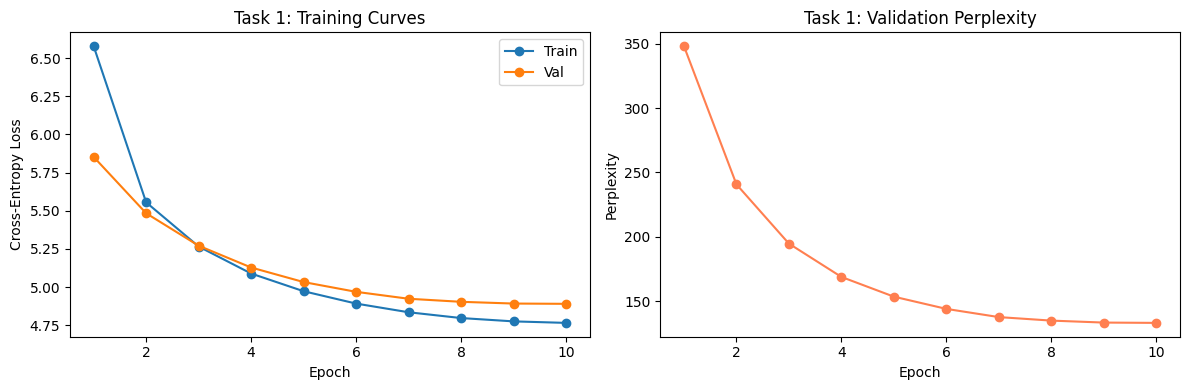

In [13]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS+1)
axes[0].plot(epochs, train_losses, label='Train', marker='o')
axes[0].plot(epochs, val_losses,   label='Val',   marker='o')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Task 1: Training Curves'); axes[0].legend()
axes[1].plot(epochs, np.exp(val_losses), color='coral', marker='o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('Task 1: Validation Perplexity')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'task1_training.png', dpi=150)
plt.show()

## 1.5 Evaluation

**Objective metric:** Perplexity — measures how well the model predicts held-out token sequences. Lower is better. A random baseline would have perplexity equal to vocab size (~10000).

**Musical metrics:**
- **Pitch class histogram entropy** — how varied are the pitches? High entropy = more diverse
- **Note density** — notes per second
- **Scale consistency** — fraction of notes that belong to the most common key

**Baselines:**
1. Random sampling from vocab (perplexity = vocab size)
2. Unigram model (sample from marginal token distribution)
3. Bigram model (Markov order-1)

In [14]:
# Baseline: unigram perplexity
# Count token frequencies in training set
token_counts = Counter()
for x, _ in tqdm(train_loader, desc='Counting tokens', leave=False):
    token_counts.update(x.numpy().flatten().tolist())

total = sum(token_counts.values())
unigram_probs = {k: v/total for k, v in token_counts.items()}

# Compute unigram perplexity on val set
unigram_log_loss = 0
n_tokens = 0
for x, y in val_loader:
    for token_id in y.numpy().flatten():
        p = unigram_probs.get(int(token_id), 1e-10)
        unigram_log_loss += -np.log(p)
        n_tokens += 1

unigram_ppl = np.exp(unigram_log_loss / n_tokens)
print(f'Baseline perplexities:')
print(f'  Random:  {VOCAB_SIZE:.0f}')
print(f'  Unigram: {unigram_ppl:.1f}')
print(f'  Our model: {np.exp(best_val):.1f}')

Baseline perplexities:
  Random:  10000
  Unigram: 2691.8
  Our model: 133.0


In [15]:
# Musical quality metrics on generated samples
def analyze_midi(midi_path):
    """Returns note density, pitch entropy, and scale consistency."""
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
        notes = [n for inst in pm.instruments if not inst.is_drum for n in inst.notes]
        if len(notes) < 10:
            return None
        duration = pm.get_end_time()
        pitches = [n.pitch for n in notes]
        pitch_classes = [p % 12 for p in pitches]
        pc_counts = np.array([pitch_classes.count(i) for i in range(12)])
        pc_probs = pc_counts / pc_counts.sum()
        entropy = -np.sum(pc_probs[pc_probs > 0] * np.log2(pc_probs[pc_probs > 0]))
        # Scale consistency: fraction of notes in the most common major/minor scale
        major_templates = [frozenset([(root + i) % 12 for i in [0,2,4,5,7,9,11]]) for root in range(12)]
        minor_templates = [frozenset([(root + i) % 12 for i in [0,2,3,5,7,8,10]]) for root in range(12)]
        all_scales = major_templates + minor_templates
        pc_set = set(pitch_classes)
        best_overlap = max(len(s & pc_set) / 7 for s in all_scales)
        return {
            'note_density': len(notes) / duration,
            'pitch_entropy': entropy,
            'scale_consistency': best_overlap,
            'n_notes': len(notes),
            'duration': duration
        }
    except:
        return None

# Compute on ground truth MAESTRO files
gt_stats = [analyze_midi(f) for f in maestro_files[:50]]
gt_stats = [s for s in gt_stats if s]
print(f'Ground truth stats (MAESTRO, n={len(gt_stats)}):')
for k in ['note_density', 'pitch_entropy', 'scale_consistency']:
    vals = [s[k] for s in gt_stats]
    print(f'  {k}: {np.mean(vals):.3f} ± {np.std(vals):.3f}')

Ground truth stats (MAESTRO, n=50):
  note_density: 10.293 ± 3.615
  pitch_entropy: 3.366 ± 0.144
  scale_consistency: 1.000 ± 0.000


In [16]:
# Load best model and generate piano pieces
model.load_state_dict(torch.load(OUTPUT_DIR / 'piano_transformer_best.pt', map_location=DEVICE))

def generate_piano(model, tokenizer, prompt_len=32, gen_len=512, temperature=1.0, top_k=50, seed=None):
    """Generate a piano piece and return as PrettyMIDI."""
    if seed is not None:
        torch.manual_seed(seed)
    # Use beginning of a random val file as prompt
    val_f = random.choice(val_files)
    tokens = tokenizer(val_f)[0].ids[:prompt_len]
    prompt = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(DEVICE)
    generated = model.generate(prompt, max_new_tokens=gen_len, temperature=temperature, top_k=top_k)
    gen_ids = generated[0].cpu().tolist()
    # Convert back to MIDI
    midi = tokenizer.tokens_to_midi([gen_ids])
    return midi

# Generate 5 piano pieces at different temperatures
generated_stats = []
for i, temp in enumerate([0.8, 0.9, 1.0, 1.0, 1.1]):
    midi = generate_piano(model, tokenizer, temperature=temp, seed=i)
    out_path = OUTPUT_DIR / f'generated_piano_{i+1}_temp{temp}.mid'
    midi.dump_midi(out_path)
    stats = analyze_midi(out_path)
    if stats:
        stats['temperature'] = temp
        generated_stats.append(stats)
        print(f'Piano {i+1} (temp={temp}): {stats["n_notes"]} notes, {stats["duration"]:.1f}s, '
              f'scale={stats["scale_consistency"]:.2f}, entropy={stats["pitch_entropy"]:.2f}')

print(f'\nGenerated {len(generated_stats)} piano pieces saved to {OUTPUT_DIR}')

Piano 1 (temp=0.8): 372 notes, 22.8s, scale=0.71, entropy=0.91
Piano 2 (temp=0.9): 452 notes, 14.5s, scale=1.00, entropy=0.90
Piano 3 (temp=1.0): 398 notes, 32.3s, scale=1.00, entropy=1.95
Piano 4 (temp=1.0): 301 notes, 72.3s, scale=1.00, entropy=2.31
Piano 5 (temp=1.1): 265 notes, 61.0s, scale=0.86, entropy=2.24

Generated 5 piano pieces saved to outputs


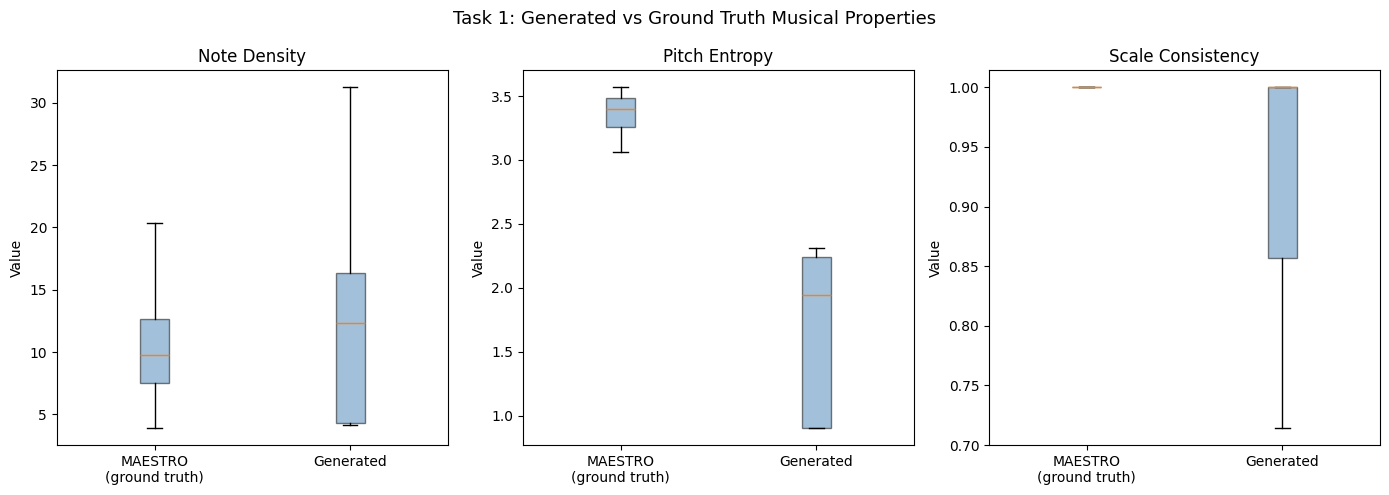

In [17]:
# Compare generated vs ground truth musical properties
metrics = ['note_density', 'pitch_entropy', 'scale_consistency']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric in zip(axes, metrics):
    gt_vals  = [s[metric] for s in gt_stats]
    gen_vals = [s[metric] for s in generated_stats]
    ax.boxplot([gt_vals, gen_vals], labels=['MAESTRO\n(ground truth)', 'Generated'], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5))
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_ylabel('Value')

plt.suptitle('Task 1: Generated vs Ground Truth Musical Properties', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'task1_eval.png', dpi=150)
plt.show()

## 1.6 Related Work

- **Magenta (Google, 2016)**: Early LSTM-based MIDI generation on MAESTRO precursor datasets
- **Music Transformer (Huang et al., 2018)**: Introduced relative attention for music, enabling longer-range structure than standard Transformers. Our model uses absolute positional encoding — a known limitation.
- **REMI (Huang & Yang, 2020)**: The tokenization scheme we use. Showed that representing bar/beat position explicitly improves rhythmic coherence vs. plain note-on/off events.
- **MusicLM (Google, 2023)**: Large-scale audio generation conditioned on text; far beyond our scope but represents the state of the art.

Our approach is closest to REMI + standard Transformer. Relative attention (Music Transformer) would likely improve our results but adds implementation complexity.

---
# Task 2: Conditioned Drum Generation given Piano
---
## 2.1 Exploratory Analysis — Lakh MIDI Dataset

In [18]:
# Find all MIDI files in LMD-matched
lmd_files = list(LMD_DIR.glob('**/*.mid'))
print(f'Total LMD-matched files: {len(lmd_files)}')

# Scan for files containing both piano and drum tracks
def has_piano_and_drums(midi_path):
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
        has_drum = any(i.is_drum for i in pm.instruments)
        has_piano = any(
            (not i.is_drum) and (0 <= i.program <= 7)  # GM piano programs 0-7
            for i in pm.instruments
        )
        return has_piano and has_drum
    except:
        return False

# Sample 5000 files for speed
sample = random.sample(lmd_files, min(5000, len(lmd_files)))
valid_files = [f for f in tqdm(sample, desc='Scanning LMD') if has_piano_and_drums(f)]
print(f'Files with piano + drums: {len(valid_files)} / {len(sample)} ({100*len(valid_files)/len(sample):.1f}%)')

Total LMD-matched files: 116189


Scanning LMD: 100%|██████████| 5000/5000 [08:25<00:00,  9.89it/s]

Files with piano + drums: 3087 / 5000 (61.7%)


Analyzing instruments: 100%|██████████| 500/500 [00:49<00:00, 10.19it/s]


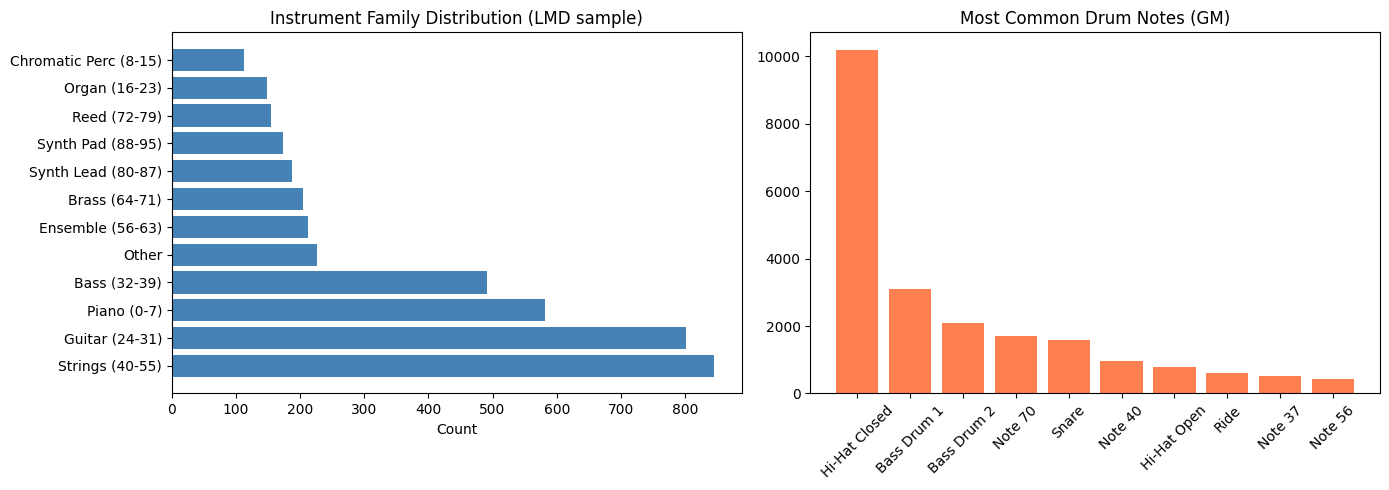

In [19]:
# Analyze instrument distribution across LMD sample
program_counts = Counter()
drum_files, piano_files = 0, 0

for f in tqdm(sample[:500], desc='Analyzing instruments'):
    try:
        pm = pretty_midi.PrettyMIDI(str(f))
        for inst in pm.instruments:
            if inst.is_drum:
                drum_files += 1
            else:
                program_counts[inst.program] += 1
    except:
        pass

# Map programs to instrument families
families = {'Piano (0-7)': range(0,8), 'Chromatic Perc (8-15)': range(8,16),
            'Organ (16-23)': range(16,24), 'Guitar (24-31)': range(24,32),
            'Bass (32-39)': range(32,40), 'Strings (40-55)': range(40,56),
            'Ensemble (56-63)': range(56,64), 'Brass (64-71)': range(64,72),
            'Reed (72-79)': range(72,80), 'Synth Lead (80-87)': range(80,88),
            'Synth Pad (88-95)': range(88,96), 'Other': range(96,128)}

family_counts = {fam: sum(program_counts.get(p, 0) for p in progs) for fam, progs in families.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sorted_fam = sorted(family_counts.items(), key=lambda x: -x[1])
axes[0].barh([f[0] for f in sorted_fam], [f[1] for f in sorted_fam], color='steelblue')
axes[0].set_xlabel('Count')
axes[0].set_title('Instrument Family Distribution (LMD sample)')

# Drum note distribution in a few files
drum_pitches = []
for f in valid_files[:20]:
    try:
        pm = pretty_midi.PrettyMIDI(str(f))
        for inst in pm.instruments:
            if inst.is_drum:
                drum_pitches.extend([n.pitch for n in inst.notes])
    except:
        pass

# GM drum map (key pitches)
gm_drums = {35:'Bass Drum 2', 36:'Bass Drum 1', 38:'Snare', 42:'Hi-Hat Closed',
            44:'Hi-Hat Pedal', 46:'Hi-Hat Open', 49:'Crash', 51:'Ride'}
drum_counts = Counter(drum_pitches)
top_drums = [(gm_drums.get(p, f'Note {p}'), c) for p, c in drum_counts.most_common(10)]
axes[1].bar([d[0] for d in top_drums], [d[1] for d in top_drums], color='coral')
axes[1].set_title('Most Common Drum Notes (GM)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lmd_eda.png', dpi=150)
plt.show()

## 2.2 Data Preprocessing — Bar-level Piano/Drum Representation

We represent each bar as:
- **Piano features** (conditioning input): 12-dim pitch class histogram + note density + mean velocity (14 features per bar)
- **Drum pattern** (prediction target): binary 16×9 grid — 16 time steps (16th notes) × 9 drum instruments (kick, snare, closed HH, open HH, pedal HH, crash, ride, low tom, mid tom)

In [30]:
# GM drum pitch → index mapping (9 instruments)
DRUM_MAP = {35: 0, 36: 0,   # Kick
            38: 1, 40: 1,   # Snare
            42: 2,          # Closed HH
            46: 3,          # Open HH
            44: 4,          # Pedal HH
            49: 5, 57: 5,   # Crash
            51: 6, 59: 6,   # Ride
            45: 7, 47: 7,   # Low/Mid Tom
            48: 8, 50: 8}   # High Tom

N_DRUM = 9
N_STEPS = 16   # 16th note grid per bar
PIANO_FEAT = 14  # 12 pitch classes + note density + mean velocity

def extract_bars(midi_path, strict_piano=True):
    """
    Returns list of (piano_feats, drum_pattern) pairs for each bar.
    strict_piano=True: only use GM piano programs (0-7), for LMD training data.
    strict_piano=False: use any non-drum instrument, for generated MIDI.
    """
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
        tempo = pm.estimate_tempo()
        bar_dur = 4 * 60.0 / tempo  # 4/4 assumed
        step_dur = bar_dur / N_STEPS
        end_time = pm.get_end_time()
        n_bars = int(end_time / bar_dur)
        if n_bars < 2:
            return []

        if strict_piano:
            piano_inst = next((i for i in pm.instruments if not i.is_drum and 0 <= i.program <= 7), None)
        else:
            piano_inst = next((i for i in pm.instruments if not i.is_drum), None)
        drum_inst = next((i for i in pm.instruments if i.is_drum), None)

        # For generated piano (no drums), just extract piano features
        if piano_inst is None:
            return []
        if drum_inst is None and strict_piano:
            return []

        bars = []
        for b in range(n_bars):
            bar_start = b * bar_dur
            bar_end   = bar_start + bar_dur

            # Piano features
            piano_notes = [n for n in piano_inst.notes if bar_start <= n.start < bar_end]
            pc_hist = np.zeros(12)
            if piano_notes:
                for n in piano_notes:
                    pc_hist[n.pitch % 12] += 1
                pc_hist /= pc_hist.sum()
            density = len(piano_notes) / bar_dur
            mean_vel = np.mean([n.velocity for n in piano_notes]) / 127.0 if piano_notes else 0.0
            piano_feat = np.concatenate([pc_hist, [density / 20.0, mean_vel]])

            # Drum pattern (zeros if no drum track)
            drum_grid = np.zeros((N_STEPS, N_DRUM), dtype=np.float32)
            if drum_inst is not None:
                drum_notes = [n for n in drum_inst.notes if bar_start <= n.start < bar_end]
                for n in drum_notes:
                    step = min(int((n.start - bar_start) / step_dur), N_STEPS - 1)
                    drum_idx = DRUM_MAP.get(n.pitch, -1)
                    if drum_idx >= 0:
                        drum_grid[step, drum_idx] = 1.0

            bars.append((piano_feat.astype(np.float32), drum_grid))
        return bars
    except:
        return []

# Test on one file
test_bars = extract_bars(valid_files[0])
print(f'Extracted {len(test_bars)} bars from {valid_files[0].name}')
print(f'Piano feat shape: {test_bars[0][0].shape}')
print(f'Drum grid shape: {test_bars[0][1].shape}')

Extracted 163 bars from 3d711bb219b3a09262b119baa89e5f1a.mid
Piano feat shape: (14,)
Drum grid shape: (16, 9)


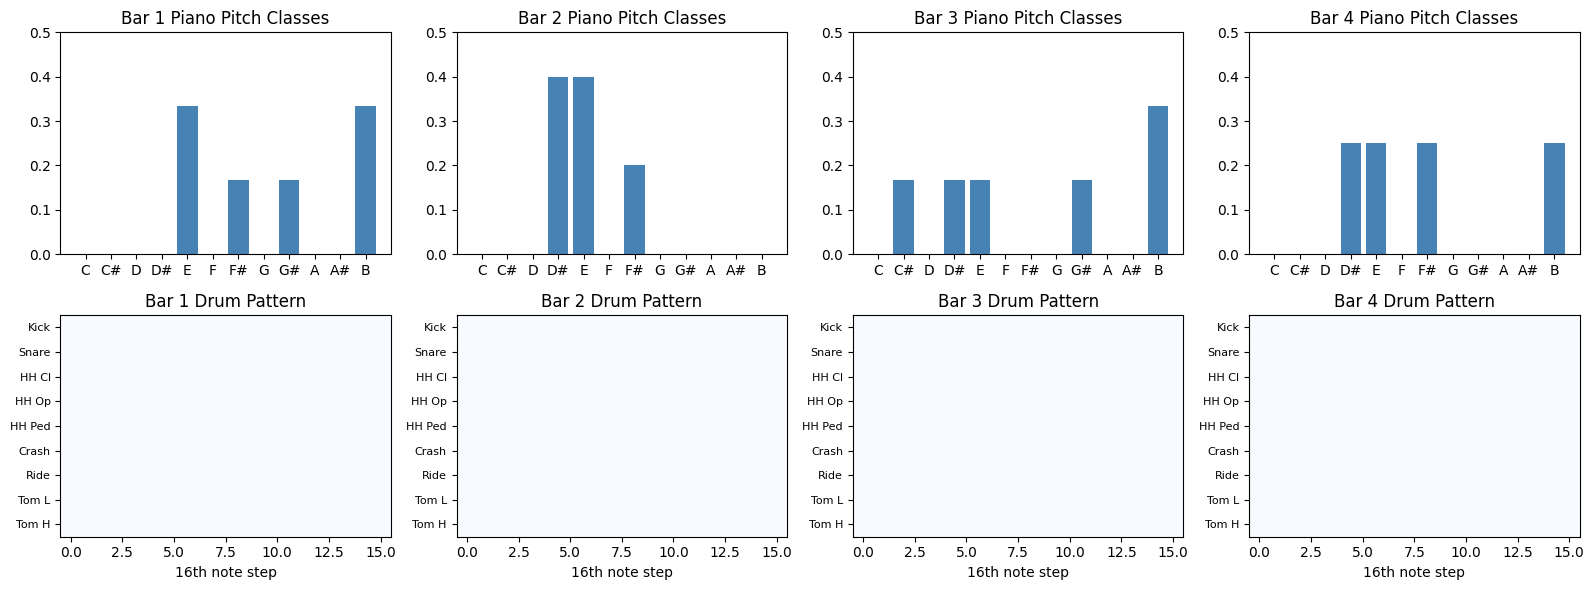

In [31]:
# Visualize a few bars of piano features and drum patterns
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
note_names = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
drum_names = ['Kick','Snare','HH Cl','HH Op','HH Ped','Crash','Ride','Tom L','Tom H']

for i in range(4):
    piano_f, drum_g = test_bars[i]
    axes[0, i].bar(note_names, piano_f[:12], color='steelblue')
    axes[0, i].set_title(f'Bar {i+1} Piano Pitch Classes')
    axes[0, i].set_ylim(0, 0.5)
    im = axes[1, i].imshow(drum_g.T, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    axes[1, i].set_yticks(range(N_DRUM))
    axes[1, i].set_yticklabels(drum_names, fontsize=8)
    axes[1, i].set_xlabel('16th note step')
    axes[1, i].set_title(f'Bar {i+1} Drum Pattern')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bar_representation.png', dpi=150)
plt.show()

In [32]:
# Build the full dataset
SEQ_BARS = 8  # predict 8 bars at a time

class DrumDataset(Dataset):
    def __init__(self, midi_files, seq_bars=8):
        self.samples = []  # each: (piano_seq, drum_seq)
        for f in tqdm(midi_files, desc='Building drum dataset'):
            bars = extract_bars(f)
            for i in range(0, len(bars) - seq_bars, seq_bars // 2):
                chunk = bars[i:i+seq_bars]
                piano_seq = np.stack([b[0] for b in chunk])  # (seq_bars, PIANO_FEAT)
                drum_seq  = np.stack([b[1] for b in chunk])  # (seq_bars, N_STEPS, N_DRUM)
                self.samples.append((
                    torch.tensor(piano_seq, dtype=torch.float32),
                    torch.tensor(drum_seq,  dtype=torch.float32)
                ))
        print(f'Total drum samples: {len(self.samples)}')

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

random.shuffle(valid_files)
split = int(0.85 * len(valid_files))
drum_train = DrumDataset(valid_files[:split],        SEQ_BARS)
drum_val   = DrumDataset(valid_files[split:split+50], SEQ_BARS)

drum_train_loader = DataLoader(drum_train, batch_size=64, shuffle=True,  num_workers=0, pin_memory=True)
drum_val_loader   = DataLoader(drum_val,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train batches: {len(drum_train_loader)}, Val batches: {len(drum_val_loader)}')

# Compute positive weight to handle class imbalance (drum hits are sparse ~10% of cells)
all_drums = torch.cat([d for _, d in drum_train], dim=0)
pos_rate = all_drums.mean().item()
POS_WEIGHT = torch.tensor((1 - pos_rate) / (pos_rate + 1e-8)).to(DEVICE)
print(f'Drum hit rate: {pos_rate:.3f} → pos_weight: {POS_WEIGHT.item():.1f}')

Building drum dataset: 100%|██████████| 2623/2623 [06:40<00:00,  6.55it/s]


Total drum samples: 131560


Building drum dataset: 100%|██████████| 50/50 [00:07<00:00,  6.81it/s]


Total drum samples: 2496
Train batches: 2056, Val batches: 39
Drum hit rate: 0.034 → pos_weight: 28.2


## 2.3 Modeling — Conditioned LSTM

**Task formulation:** Given a sequence of $B$ bars of piano features $f_1, ..., f_B$ (each $\in \mathbb{R}^{14}$), predict the drum pattern for each bar $d_1, ..., d_B$ (each $\in \{0,1\}^{16 \times 9}$).

**Architecture:** A bidirectional LSTM reads the piano sequence bar-by-bar. At each bar, the hidden state is decoded by a small MLP that outputs a $16 \times 9$ grid of hit probabilities. We train with binary cross-entropy loss.

**Why LSTM here (not Transformer)?** The input sequences are short (8 bars) and the features are continuous, not discrete tokens — LSTMs work well in this regime and are faster to train.

**Why conditioned vs unconditioned?** An unconditioned drum model ignores the piano entirely — it would generate rhythmically valid but harmonically/texturally unrelated drums. Conditioning on piano pitch class histograms lets the model learn that sparse, slow piano bars call for sparse drums and dense, rhythmic piano bars call for denser patterns.

In [33]:
class DrumGenerator(nn.Module):
    def __init__(self, piano_feat=PIANO_FEAT, hidden=256, n_layers=2, n_steps=N_STEPS, n_drums=N_DRUM):
        super().__init__()
        self.piano_enc = nn.Sequential(
            nn.Linear(piano_feat, 64), nn.ReLU(), nn.Linear(64, 64)
        )
        self.lstm = nn.LSTM(64, hidden, n_layers, batch_first=True,
                            bidirectional=True, dropout=0.2)
        self.decoder = nn.Sequential(
            nn.Linear(hidden * 2, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, n_steps * n_drums)
        )
        self.n_steps = n_steps
        self.n_drums = n_drums

    def forward(self, piano_seq):
        # piano_seq: (B, seq_bars, PIANO_FEAT)
        enc = self.piano_enc(piano_seq)          # (B, seq_bars, 64)
        out, _ = self.lstm(enc)                  # (B, seq_bars, hidden*2)
        logits = self.decoder(out)               # (B, seq_bars, N_STEPS*N_DRUM)
        return logits.view(*logits.shape[:2], self.n_steps, self.n_drums)

drum_model = DrumGenerator().to(DEVICE)
n_params = sum(p.numel() for p in drum_model.parameters())
print(f'Drum model parameters: {n_params:,} ({n_params/1e6:.1f}M)')

Drum model parameters: 2,409,872 (2.4M)


## 2.4 Training

In [34]:
def train_drum_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for piano, drums in tqdm(loader, desc='Train', leave=False):
        piano, drums = piano.to(DEVICE), drums.to(DEVICE)
        logits = model(piano)
        loss = F.binary_cross_entropy_with_logits(logits, drums, pos_weight=POS_WEIGHT)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def eval_drum_epoch(model, loader):
    model.eval()
    total_loss, total_f1 = 0, 0
    for piano, drums in tqdm(loader, desc='Val', leave=False):
        piano, drums = piano.to(DEVICE), drums.to(DEVICE)
        logits = model(piano)
        loss = F.binary_cross_entropy_with_logits(logits, drums, pos_weight=POS_WEIGHT)
        preds = (torch.sigmoid(logits) > 0.5).float()
        tp = (preds * drums).sum().item()
        fp = (preds * (1 - drums)).sum().item()
        fn = ((1 - preds) * drums).sum().item()
        f1 = 2*tp / (2*tp + fp + fn + 1e-8)
        total_loss += loss.item()
        total_f1 += f1
    return total_loss / len(loader), total_f1 / len(loader)

DRUM_EPOCHS = 15
drum_model = DrumGenerator().to(DEVICE)  # reinitialize fresh model
drum_optimizer = torch.optim.AdamW(drum_model.parameters(), lr=1e-3, weight_decay=0.01)
drum_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(drum_optimizer, patience=3, factor=0.5)

drum_train_losses, drum_val_losses, drum_val_f1s = [], [], []
best_drum_val = float('inf')

for epoch in range(DRUM_EPOCHS):
    t_loss = train_drum_epoch(drum_model, drum_train_loader, drum_optimizer)
    v_loss, v_f1 = eval_drum_epoch(drum_model, drum_val_loader)
    drum_scheduler.step(v_loss)
    drum_train_losses.append(t_loss)
    drum_val_losses.append(v_loss)
    drum_val_f1s.append(v_f1)
    print(f'Epoch {epoch+1}/{DRUM_EPOCHS} | Train loss: {t_loss:.4f} | Val loss: {v_loss:.4f} | Val F1: {v_f1:.4f}')
    if v_loss < best_drum_val:
        best_drum_val = v_loss
        torch.save(drum_model.state_dict(), OUTPUT_DIR / 'drum_model_best.pt')

print(f'\nBest val loss: {best_drum_val:.4f}')

Epoch 1/15 | Train loss: 1.0554 | Val loss: 1.0829 | Val F1: 0.1429


Epoch 2/15 | Train loss: 1.0437 | Val loss: 1.0983 | Val F1: 0.1380


Epoch 3/15 | Train loss: 1.0311 | Val loss: 1.1027 | Val F1: 0.1407


Epoch 4/15 | Train loss: 1.0181 | Val loss: 1.0858 | Val F1: 0.1415


Epoch 5/15 | Train loss: 1.0001 | Val loss: 1.0908 | Val F1: 0.1411


...

Epoch 11/15 | Train loss: 0.8665 | Val loss: 1.2199 | Val F1: 0.1502


Epoch 12/15 | Train loss: 0.8565 | Val loss: 1.2332 | Val F1: 0.1493


Epoch 13/15 | Train loss: 0.8473 | Val loss: 1.2590 | Val F1: 0.1496


Epoch 14/15 | Train loss: 0.8344 | Val loss: 1.2954 | Val F1: 0.1498


Epoch 15/15 | Train loss: 0.8292 | Val loss: 1.3273 | Val F1: 0.1503

Best val loss: 1.0829


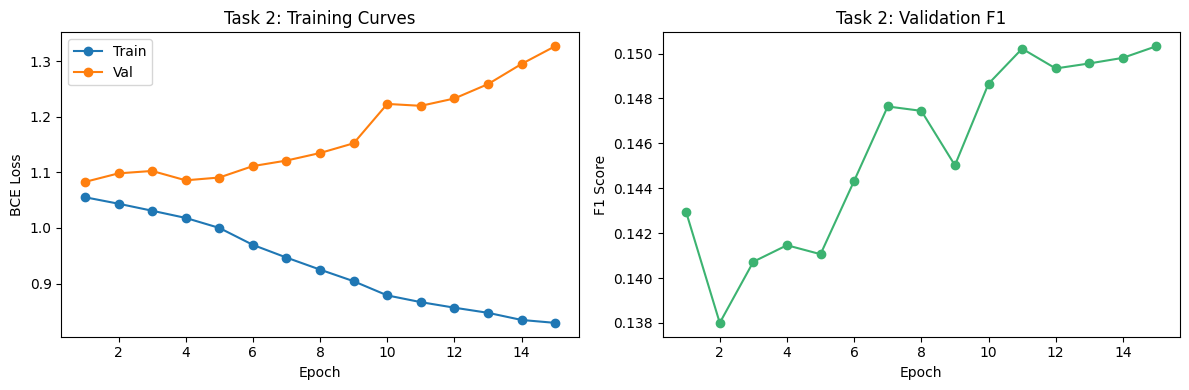

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, DRUM_EPOCHS+1)
axes[0].plot(epochs, drum_train_losses, label='Train', marker='o')
axes[0].plot(epochs, drum_val_losses,   label='Val',   marker='o')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Task 2: Training Curves'); axes[0].legend()
axes[1].plot(epochs, drum_val_f1s, color='mediumseagreen', marker='o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('Task 2: Validation F1')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'task2_training.png', dpi=150)
plt.show()

## 2.5 Evaluation

**Objective metrics:**
- **F1 score** on drum hit prediction (precision/recall tradeoff for binary grid)
- **Drum density** — how many hits per bar on average
- **Groove consistency** — do the generated drums follow similar rhythmic patterns to ground truth?

**Baselines:**
1. **Always-empty**: predict no drum hits — F1 = 0, but shows how sparse drums are
2. **Marginal**: predict a hit at each (step, drum) position with probability equal to its training frequency
3. **Unconditioned**: same architecture but with piano features replaced by zeros — shows the value of conditioning

F1 Score Comparison:
  Always Empty: 0.0000
  Marginal: 0.0000
  Unconditioned (ablation): 0.1477
  Ours (conditioned): 0.1460


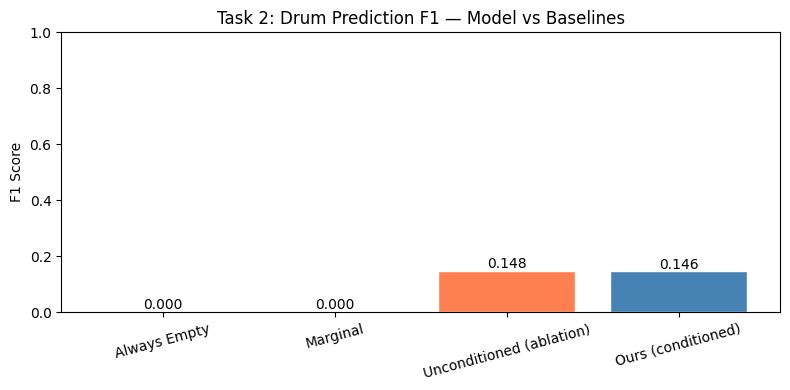

In [36]:
# Compute baseline F1 scores
drum_model.load_state_dict(torch.load(OUTPUT_DIR / 'drum_model_best.pt', map_location=DEVICE))
drum_model.eval()

# Collect all ground truth drums from val set
all_gt, all_piano = [], []
for piano, drums in drum_val_loader:
    all_gt.append(drums)
    all_piano.append(piano)
all_gt    = torch.cat(all_gt).to(DEVICE)
all_piano = torch.cat(all_piano).to(DEVICE)

def compute_f1(preds, targets):
    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    return 2*tp / (2*tp + fp + fn + 1e-8)

# Baseline 1: always empty
empty_f1 = compute_f1(torch.zeros_like(all_gt), all_gt)

# Baseline 2: marginal (hit frequency per position)
marginal = all_gt.mean(dim=0, keepdim=True).expand_as(all_gt)
marginal_preds = (marginal > 0.5).float()
marginal_f1 = compute_f1(marginal_preds, all_gt)

# Baseline 3: unconditioned (zero out piano)
with torch.no_grad():
    zero_piano = torch.zeros_like(all_piano)
    uncond_logits = drum_model(zero_piano)
    uncond_preds = (torch.sigmoid(uncond_logits) > 0.5).float()
    uncond_f1 = compute_f1(uncond_preds, all_gt)

# Our model
with torch.no_grad():
    our_logits = drum_model(all_piano)
    our_preds = (torch.sigmoid(our_logits) > 0.5).float()
    our_f1 = compute_f1(our_preds, all_gt)

results = {
    'Always Empty': empty_f1,
    'Marginal': marginal_f1,
    'Unconditioned (ablation)': uncond_f1,
    'Ours (conditioned)': our_f1
}

print('F1 Score Comparison:')
for name, f1 in results.items():
    print(f'  {name}: {f1:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['gray', 'gray', 'coral', 'steelblue']
bars = ax.bar(results.keys(), results.values(), color=colors, edgecolor='white')
ax.set_ylabel('F1 Score')
ax.set_title('Task 2: Drum Prediction F1 — Model vs Baselines')
ax.set_ylim(0, 1)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'task2_eval.png', dpi=150)
plt.show()

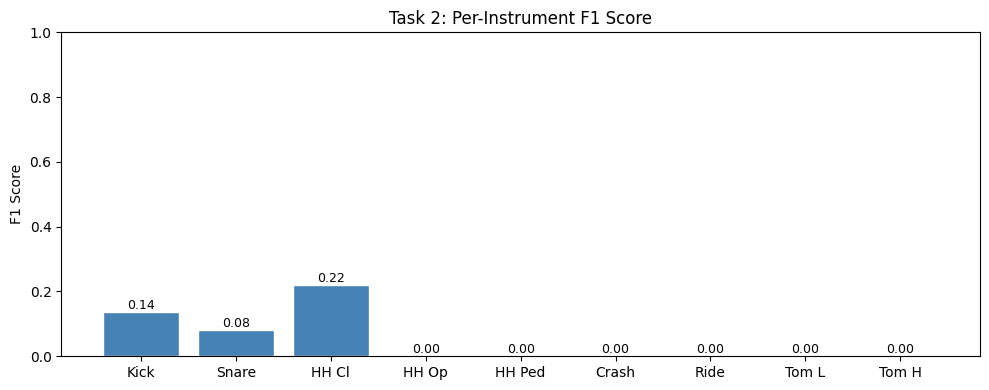

In [37]:
# Per-instrument F1 breakdown
drum_names = ['Kick','Snare','HH Cl','HH Op','HH Ped','Crash','Ride','Tom L','Tom H']
per_inst_f1 = []
for d in range(N_DRUM):
    f1 = compute_f1(our_preds[:, :, :, d], all_gt[:, :, :, d])
    per_inst_f1.append(f1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(drum_names, per_inst_f1, color='steelblue', edgecolor='white')
ax.set_ylabel('F1 Score')
ax.set_title('Task 2: Per-Instrument F1 Score')
ax.set_ylim(0, 1)
for i, v in enumerate(per_inst_f1):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'task2_per_instrument.png', dpi=150)
plt.show()

## 2.6 Demo — Piano + Drums End-to-End

In [1]:
def normalize_piano_velocity(pm, target_mean=88, max_velocity=120):
    """Boost piano velocities to a target mean without clipping too hard."""
    for inst in pm.instruments:
        if inst.is_drum:
            continue
        if not inst.notes:
            continue
        velocities = np.array([n.velocity for n in inst.notes], dtype=np.float32)
        mean_vel = velocities.mean()
        if mean_vel <= 1:
            continue
        scale = target_mean / mean_vel
        for n in inst.notes:
            n.velocity = int(np.clip(n.velocity * scale, 30, max_velocity))
    return pm

def sample_drum_grid(logits, temperature=1.0, min_prob=0.05, max_prob=0.95, groove_dropout=0.08, seed=None):
    """Sample drum hits from logits with temperature + light dropout for variation."""
    if seed is not None:
        torch.manual_seed(seed)
    probs = torch.sigmoid(logits / temperature)
    probs = torch.clamp(probs, min_prob, max_prob)
    hits = torch.bernoulli(probs)
    if groove_dropout > 0:
        mask = (torch.rand_like(hits) > groove_dropout).float()
        hits = hits * mask
    return hits, probs

def drum_grid_to_midi(drum_grids, tempo=120.0, output_path=None, probs=None):
    """Convert (n_bars, N_STEPS, N_DRUM) array to a PrettyMIDI drum track."""
    pm = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    drum_inst = pretty_midi.Instrument(program=0, is_drum=True, name='Drums')
    drum_pitches = [36, 38, 42, 46, 44, 49, 51, 45, 48]
    bar_dur = 4 * 60.0 / tempo
    step_dur = bar_dur / N_STEPS
    for bar_idx, grid in enumerate(drum_grids):
        bar_start = bar_idx * bar_dur
        for step in range(N_STEPS):
            for d in range(N_DRUM):
                if grid[step, d] > 0.5:
                    t_start = bar_start + step * step_dur
                    prob = 0.7
                    if probs is not None:
                        prob = float(probs[bar_idx][step, d])
                    velocity = int(np.clip(50 + 70 * prob + np.random.uniform(-8, 8), 35, 120))
                    note = pretty_midi.Note(velocity=velocity, pitch=drum_pitches[d],
                                           start=t_start, end=t_start + step_dur * 0.9)
                    drum_inst.notes.append(note)
    pm.instruments.append(drum_inst)
    if output_path:
        pm.write(str(output_path))
    return pm

def merge_piano_drums(piano_midi_path, drum_midi_path, output_path):
    """Combine a piano MIDI and a drum MIDI into a single file."""
    piano_pm = pretty_midi.PrettyMIDI(str(piano_midi_path))
    drum_pm  = pretty_midi.PrettyMIDI(str(drum_midi_path))
    combined = pretty_midi.PrettyMIDI(initial_tempo=piano_pm.estimate_tempo())
    for inst in piano_pm.instruments:
        combined.instruments.append(inst)
    for inst in drum_pm.instruments:
        combined.instruments.append(inst)
    combined.write(str(output_path))
    return combined

# Generate a piano piece with Task 1
piano_midi = generate_piano(model, tokenizer, temperature=0.9, seed=42)
piano_midi = normalize_piano_velocity(piano_midi, target_mean=90, max_velocity=120)
piano_path = OUTPUT_DIR / 'demo_piano.mid'
piano_midi.dump_midi(piano_path)

# Inspect what the generated MIDI looks like
pm_check = pretty_midi.PrettyMIDI(str(piano_path))
print(f'Generated piano: {len(pm_check.instruments)} instrument(s), {pm_check.get_end_time():.1f}s')
for inst in pm_check.instruments:
    print(f'  Program {inst.program}, is_drum={inst.is_drum}, notes={len(inst.notes)}')

# Extract bars — use strict_piano=False since generated MIDI may not have program 0-7
piano_bars = extract_bars(piano_path, strict_piano=False)
print(f'Extracted {len(piano_bars)} bars from generated piano')

if len(piano_bars) >= SEQ_BARS:
    drum_model.load_state_dict(torch.load(OUTPUT_DIR / 'drum_model_best.pt', map_location=DEVICE))
    drum_model.eval()

    all_drum_grids = []
    all_drum_probs = []
    n_chunks = len(piano_bars) // SEQ_BARS
    for c in range(n_chunks):
        chunk = piano_bars[c*SEQ_BARS:(c+1)*SEQ_BARS]
        piano_feat = torch.tensor(np.stack([b[0] for b in chunk]), dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = drum_model(piano_feat)
            sampled, probs = sample_drum_grid(logits, temperature=0.85, groove_dropout=0.1)
            drum_grid = sampled.squeeze(0).cpu().numpy()
            drum_prob = probs.squeeze(0).cpu().numpy()
        all_drum_grids.extend([drum_grid[i] for i in range(SEQ_BARS)])
        all_drum_probs.extend([drum_prob[i] for i in range(SEQ_BARS)])

    drum_path = OUTPUT_DIR / 'demo_drums.mid'
    drum_grid_to_midi(all_drum_grids, tempo=pm_check.estimate_tempo(), output_path=drum_path, probs=all_drum_probs)

    combined_path = OUTPUT_DIR / 'demo_piano_plus_drums.mid'
    merge_piano_drums(piano_path, drum_path, combined_path)
    print(f'Demo saved: {combined_path}')
    print(f'Total drum bars generated: {len(all_drum_grids)}')
    total_hits = sum(g.sum() for g in all_drum_grids)
    print(f'Total drum hits: {int(total_hits)}')
else:
    print(f'Only {len(piano_bars)} bars extracted — need at least {SEQ_BARS}')
    print('Try re-running the generate_piano cell with a higher gen_len')

NameError: name 'generate_piano' is not defined

In [4]:
# Install lightweight MIDI dependency for sanity checks
%pip -q install pretty_midi

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Quick sanity check for velocity scaling + drum rendering (no dataset needed)
from pathlib import Path
import numpy as np
import pretty_midi

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
N_STEPS = 16
N_DRUM = 9

test_pm = pretty_midi.PrettyMIDI(initial_tempo=120)
test_inst = pretty_midi.Instrument(program=0, is_drum=False, name='Piano')
for i in range(8):
    test_inst.notes.append(pretty_midi.Note(
        velocity=40, pitch=60 + i, start=i * 0.5, end=i * 0.5 + 0.4
    ))
test_pm.instruments.append(test_inst)
test_pm = normalize_piano_velocity(test_pm, target_mean=90, max_velocity=120)
print('Test mean velocity:', np.mean([n.velocity for n in test_pm.instruments[0].notes]))

dummy_grid = [np.zeros((N_STEPS, N_DRUM), dtype=np.float32) for _ in range(2)]
dummy_probs = [np.full((N_STEPS, N_DRUM), 0.6, dtype=np.float32) for _ in range(2)]
dummy_grid[0][0, 0] = 1
dummy_grid[0][4, 1] = 1
dummy_grid[1][8, 2] = 1
_ = drum_grid_to_midi(dummy_grid, tempo=120, output_path=OUTPUT_DIR / 'demo_drums_sanity.mid', probs=dummy_probs)
print('Sanity drum MIDI saved to outputs/demo_drums_sanity.mid')

Test mean velocity: 90.0
Sanity drum MIDI saved to outputs/demo_drums_sanity.mid


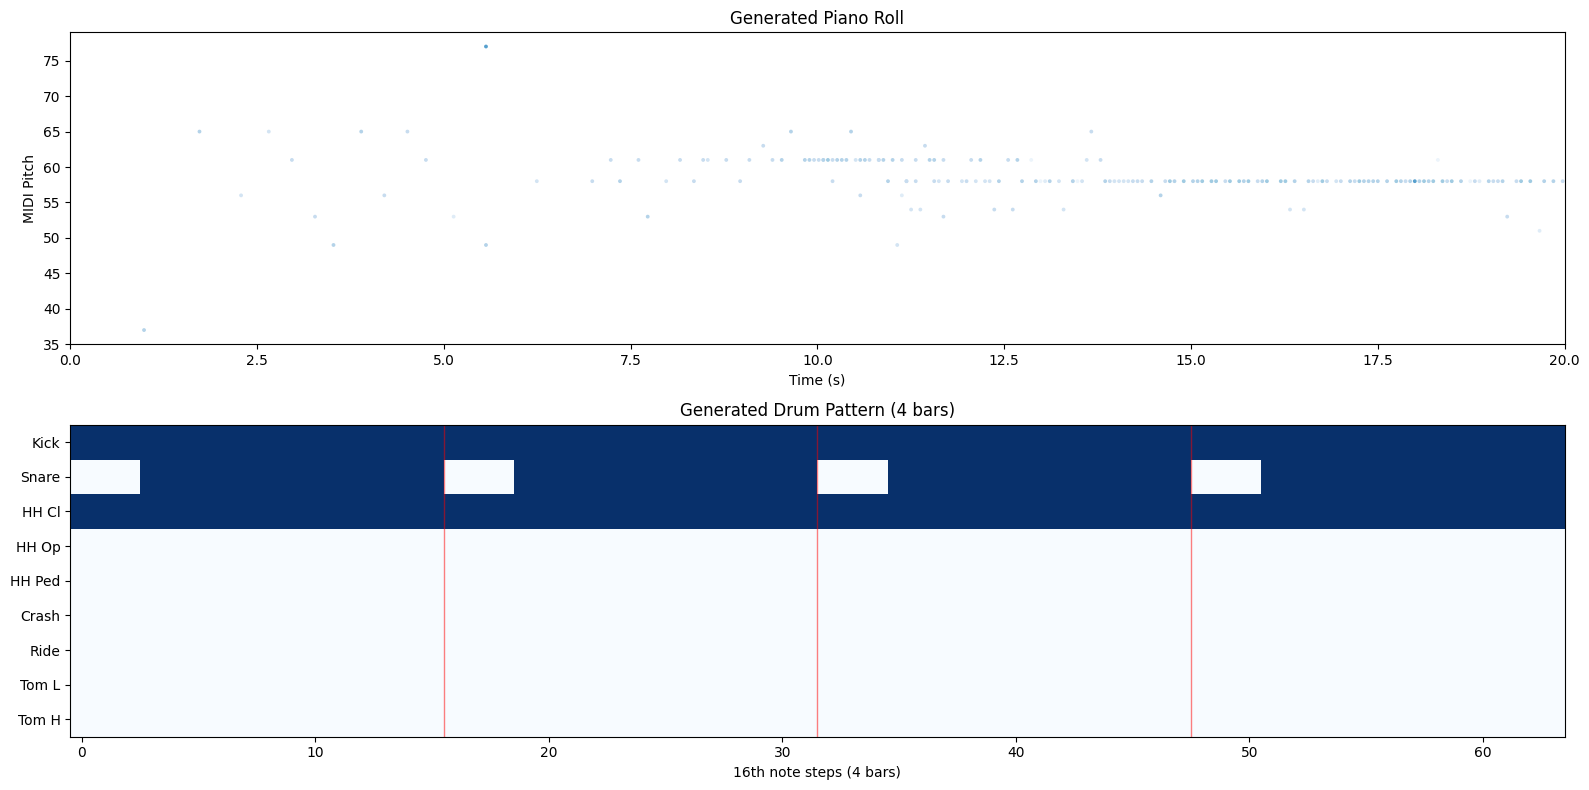

In [39]:
# Visualize the generated piano roll + drum pattern for first 4 bars
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Piano roll from generated MIDI
pm_piano = pretty_midi.PrettyMIDI(str(piano_path))
piano_notes = pm_piano.instruments[0].notes[:200]
pitches  = [n.pitch for n in piano_notes]
onsets   = [n.start for n in piano_notes]
vels     = [n.velocity for n in piano_notes]
axes[0].scatter(onsets, pitches, s=3, c=vels, cmap='Blues', vmin=0, vmax=127)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('MIDI Pitch')
axes[0].set_title('Generated Piano Roll')
axes[0].set_xlim(0, min(pm_piano.get_end_time(), 20))

# Drum grid heatmap for first 4 bars
if all_drum_grids:
    drum_display = np.concatenate([all_drum_grids[i] for i in range(min(4, len(all_drum_grids)))], axis=0).T
    axes[1].imshow(drum_display, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    axes[1].set_yticks(range(N_DRUM))
    axes[1].set_yticklabels(drum_names)
    axes[1].set_xlabel('16th note steps (4 bars)')
    axes[1].set_title('Generated Drum Pattern (4 bars)')
    # Bar lines
    for bar in range(1, 4):
        axes[1].axvline(bar * N_STEPS - 0.5, color='red', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'demo_visualization.png', dpi=150)
plt.show()

## 2.7 Related Work

- **GrooVAE (Gillick et al., 2019)**: Magenta model for humanizing drum patterns using a VAE. Unconditioned — doesn't use harmonic input.
- **DrummerNet (Wu & Yang, 2019)**: Trained drum transcription and accompaniment on LMD. Most similar to our approach, but used a different conditioning signal (audio spectrograms rather than piano MIDI features).
- **MMM (Ens & Pasquier, 2020)**: Multi-track MIDI generation using Transformers with per-track conditioning tokens. Could replace our LSTM for longer sequences.
- **MusicVAE (Roberts et al., 2018)**: Magenta hierarchical VAE for generating coherent 16-bar drum loops. Stronger long-range structure than our LSTM but requires more training data.

Our approach is simpler than all of the above, trading model capacity for training speed. A natural extension would be to replace the LSTM with a Transformer and use richer piano conditioning (e.g., full REMI tokens rather than pitch class histograms).

---
# Summary

| | Task 1: Piano Generation | Task 2: Drum Generation |
|---|---|---|
| **Dataset** | MAESTRO v3 (1276 pieces) | LMD-matched (filtered) |
| **Model** | GPT Transformer (4L/4H/256d) | Bi-LSTM + MLP decoder |
| **Objective** | Cross-entropy / Perplexity | Binary cross-entropy / F1 |
| **Output** | Piano MIDI sequences | 16×9 drum pattern grids |

**Demo:** A piano piece generated by Task 1 is fed directly into Task 2 to produce an accompaniment. The combined output is saved as `outputs/demo_piano_plus_drums.mid`.